# A2 · 貝葉斯生存分析(二):模型比較與刪失的資訊代價

接續 `01_censoring_likelihood.ipynb`。這本處理:

1. **通關標準 3**:`az.compare` 排序 Weibull / Log-Normal / Exponential,並解釋 WAIC 的懲罰項
2. WAIC 為什麼這樣排?—— 用**風險函數形狀**給出機制解釋
3. 誠實面:WAIC 明確排序,但樣本外**判別力**分不出來
4. **刪失的資訊代價**:三臂實驗,結果推翻了「精度只由事件數決定」

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
import arviz as az
from IPython.display import Image, display
import data as D, censoring as cn, models as M, frequentist as fq, evaluate as ev
DATA = os.path.abspath('../../data/A_medical')
FIG  = os.path.abspath('../figures')
RES  = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
print('results.json from a', RES['_meta']['runtime_sec'], 'sec full run')


results.json from a 389.9 sec full run


## 1. 通關標準 3:WAIC / LOO 排序三個基準分佈

比較的是**基準風險的形狀**,三者都用同一組 AFT 係數結構:

| 分佈 | $S(t)$ | 風險率 $h(t)$ 的形狀 |
|---|---|---|
| Exponential | $e^{-t/\lambda}$ | **恆定**(Weibull 的 $k=1$ 特例) |
| Weibull | $e^{-(t/\lambda)^k}$ | **單調**:$k>1$ 遞增、$k<1$ 遞減 |
| Log-Normal | $1-\Phi\!\big(\tfrac{\log t-\log\lambda}{\sigma}\big)$ | **先升後降**,有單一峰值 |

> 💡 為什麼不用貝氏因子?因為它對先驗太敏感(Lindley 悖論)。B2 專案用
> injection–recovery 實測過:先驗只放寬 3 倍就能讓結論翻盤。
> WAIC/LOO 估計的是**樣本外預測表現**,對弱資訊先驗的具體寬度遠不敏感。

In [2]:
ic = pd.DataFrame(RES['ic_table']).T
ic = ic.loc[ic['elpd_waic'].sort_values(ascending=False).index]
display(ic[['elpd_waic','se_waic','p_waic','elpd_loo','p_loo',
            'n_params_stated','max_pareto_k']].round(2))

w = RES['waic_winner']
print(f"勝者:{w['best']}   Δelpd vs {w['second']} = {w['elpd_diff']:.2f}"
      f"  (dse = {w['se_diff']:.2f} → {w['sigma']:.1f}σ)")
print(f"最大 Pareto k = {ic['max_pareto_k'].max():.2f}  (<0.7 → LOO 估計可靠)")

,elpd_waic,se_waic,p_waic,elpd_loo,p_loo,n_params_stated,max_pareto_k
lognormal,-790.99,23.01,9.50,-791.01,9.52,10.0,0.44
weibull,-811.64,23.79,10.18,-811.67,10.21,10.0,0.39
exponential,-832.61,24.84,7.60,-832.62,7.62,9.0,0.29


勝者:lognormal   Δelpd vs weibull = 20.65  (dse = 4.26 → 4.8σ)
最大 Pareto k = 0.44  (<0.7 → LOO 估計可靠)


### WAIC 的懲罰項在做什麼

$$\mathrm{elpd}_{\mathrm{WAIC}} = \underbrace{\sum_i \log \mathbb{E}_{\text{post}}\,p(y_i|\theta)}_{\text{擬合}}
- \underbrace{\sum_i \mathrm{Var}_{\text{post}}\big(\log p(y_i|\theta)\big)}_{p_{\mathrm{WAIC}}\;=\;\text{有效參數數}}$$

$p_{\mathrm{WAIC}}$ **不是**「你寫了幾個參數」,而是資料實際「用掉」多少自由度:
如果某個參數被資料緊緊約束,該觀測的 log-likelihood 在後驗上變動就小,
貢獻的懲罰也小。這是它比 AIC(固定懲罰 $k$)與 BIC($k\log n/2$)更貼近實情的地方 ——
B2 專案裡就實測到 BIC 在邊緣案例上判到反邊。

In [3]:
for m in ic.index:
    print(f"{m:12s}  寫了 {int(ic.loc[m,'n_params_stated']):2d} 個參數"
          f"   p_waic = {ic.loc[m,'p_waic']:.2f}"
          f"   p_loo = {ic.loc[m,'p_loo']:.2f}")
print()
print('Exponential 少一個形狀參數,p_waic 也確實最小。')
print('三者的 p_waic 都與寫出的參數數同量級但不相等 —— 部分自由度被先驗與資料吃掉了。')

lognormal     寫了 10 個參數   p_waic = 9.50   p_loo = 9.52
weibull       寫了 10 個參數   p_waic = 10.18   p_loo = 10.21
exponential   寫了  9 個參數   p_waic = 7.60   p_loo = 7.62

Exponential 少一個形狀參數,p_waic 也確實最小。
三者的 p_waic 都與寫出的參數數同量級但不相等 —— 部分自由度被先驗與資料吃掉了。


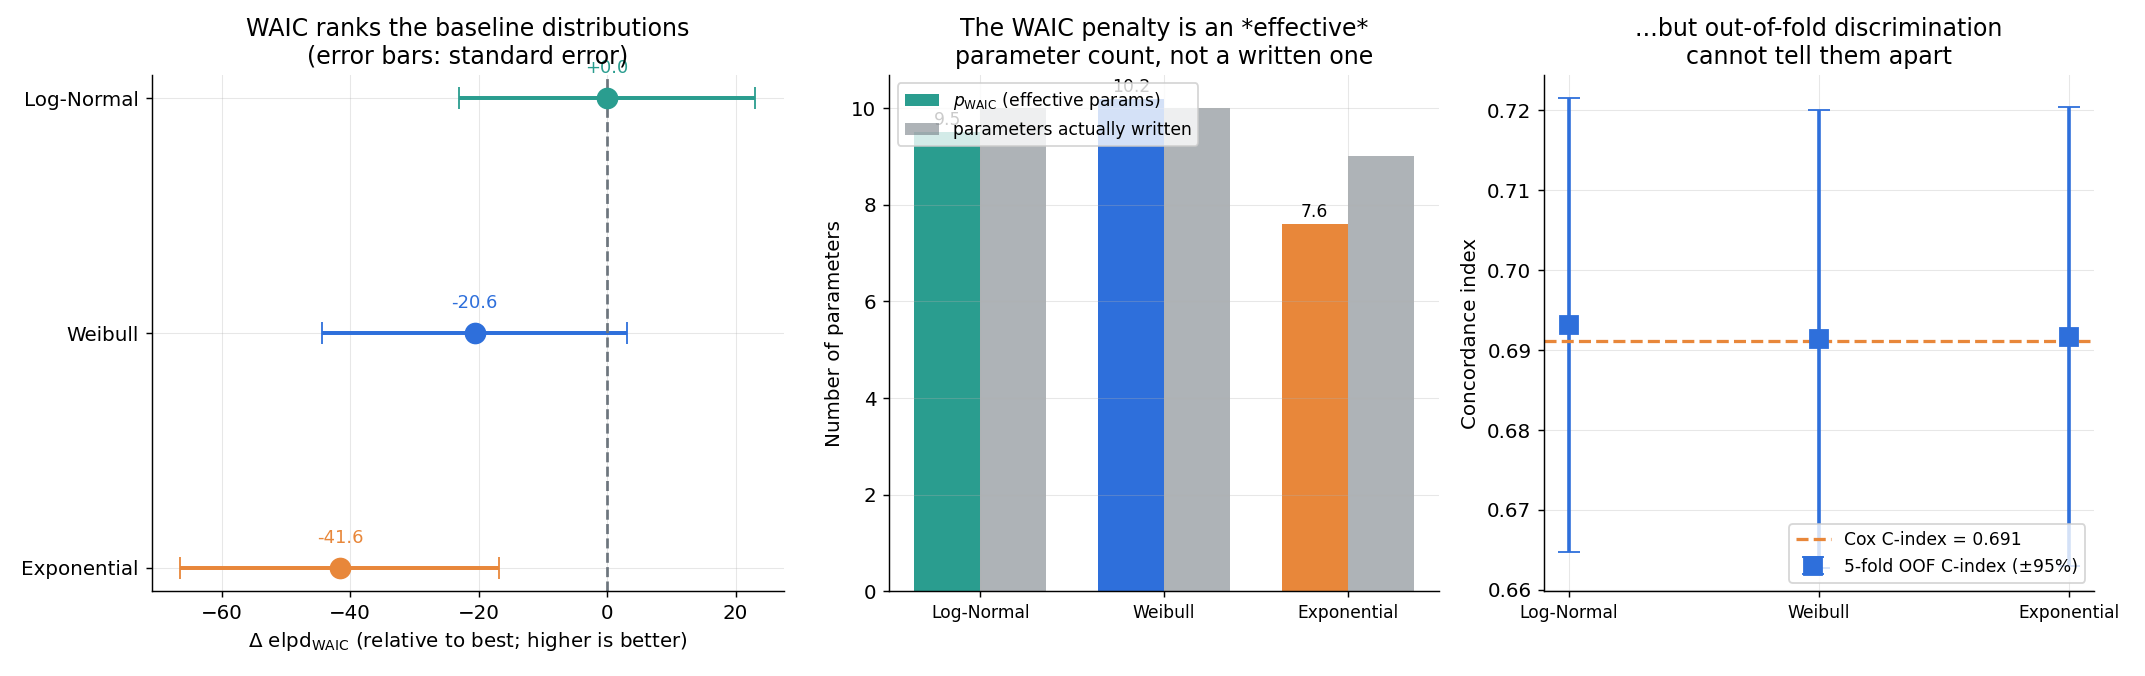

In [4]:
display(Image(os.path.join(FIG, '04_model_comparison.png')))

## 2. 為什麼 Log-Normal 贏?—— 看風險函數,不是看分數

排名本身沒有解釋力。真正的問題是「這個疾病的風險隨時間怎麼走」,
而三個分佈對這件事的假設被硬性限制住(見上表)。

存活曲線 $S(t)$ 長得像的兩個模型,風險率 $h(t)=f(t)/S(t)$ 可以差很多,
而 $h(t)$ 才是「此刻的危險程度」—— 臨床上真正驅動追蹤頻率決策的量。

### 先解決一個容易搞錯的比較

要跟非參數的 Nelson–Aalen 估計比,必須用**族群層級**(marginal)風險:

$$h_{\mathrm{pop}}(t) = \frac{\sum_i S_i(t)\,h_i(t)}{\sum_i S_i(t)}$$

而**不是**平均病人的 $h(t|\bar{x})$。兩者不同不是誤差,是真實的統計現象:
族群裡有異質性,高風險的人先離開風險集合,剩下的是低風險者 →
**族群風險率的峰值比任何個體的峰值都更早、下降也更快**
(unobserved heterogeneity / frailty 效應)。
拿 $h(t|\bar{x})$ 去對 Nelson–Aalen,會誤判模型與資料不合。

In [5]:
pk = RES['hazard_peaks']
print(f"非參數(Nelson–Aalen)族群峰值 : {pk['na_peak']:.2f} 年")
print(f"   對核寬度的敏感度: {pk['na_peak_by_bandwidth']}")
print('   → 在 bw=0.3~0.6 完全穩定,不是平滑參數的產物。')
print()
for kind in ['lognormal','weibull','exponential']:
    p = pk[f'{kind}_pop']
    print(f"{kind:12s} 個體峰值 {pk[f'{kind}_ind_peak']:.2f} 年 | "
          f"族群峰值 {p['median']:.2f} 年 [{p['lo']:.2f}, {p['hi']:.2f}]")
print()
kk = RES['weibull_shape_k']
print(f"Weibull shape k = {kk['median']:.3f} [{kk['lo95']:.3f}, {kk['hi95']:.3f}], "
      f"P(k>1) = {kk['p_k_gt_1']:.4f}")
print('k 明確 > 1 → Weibull 只能給「單調遞增」的風險,峰值被推到追蹤期末端;')
print('Exponential 更僵硬,只能給一條水平線。這就是它們輸掉的原因。')

非參數(Nelson–Aalen)族群峰值 : 1.40 年
   對核寬度的敏感度: {'0.3': 1.4016589519599998, '0.45': 1.4016589519599998, '0.6': 1.4016589519599998, '0.9': 1.2014037285815382}
   → 在 bw=0.3~0.6 完全穩定,不是平滑參數的產物。

lognormal    個體峰值 3.09 年 | 族群峰值 2.04 年 [1.60, 2.52]
weibull      個體峰值 7.00 年 | 族群峰值 4.96 年 [2.79, 7.00]
exponential  個體峰值 0.02 年 | 族群峰值 0.02 年 [0.02, 0.02]

Weibull shape k = 1.391 [1.260, 1.528], P(k>1) = 1.0000
k 明確 > 1 → Weibull 只能給「單調遞增」的風險,峰值被推到追蹤期末端;
Exponential 更僵硬,只能給一條水平線。這就是它們輸掉的原因。


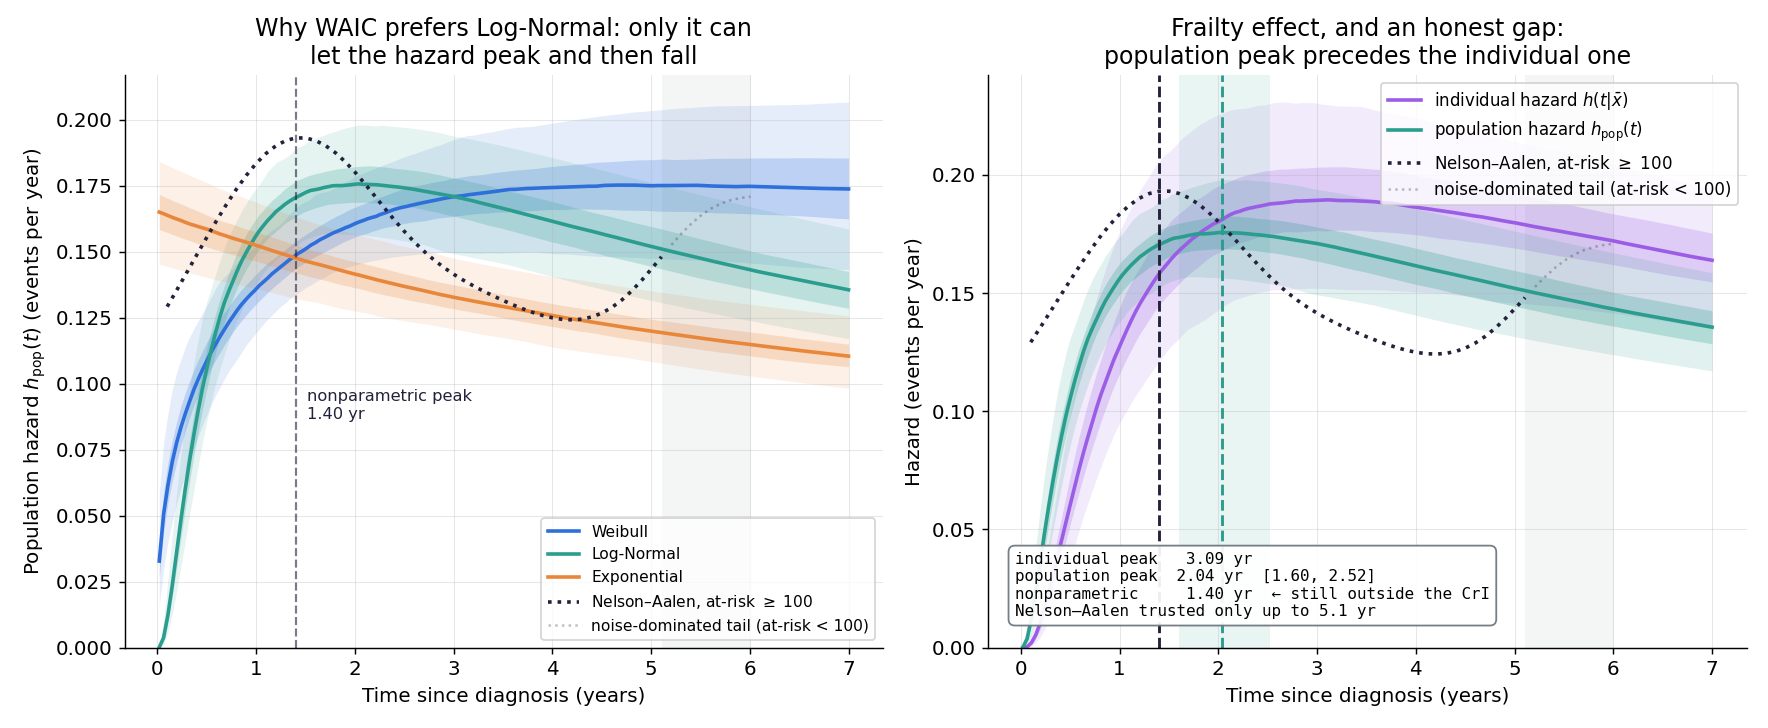

In [6]:
display(Image(os.path.join(FIG, '05_hazard_shapes.png')))

### 誠實地看這個結果

Log-Normal 是三者中**唯一**能讓風險先升後降的,族群峰值約 2.0 年,
比 Weibull(被推到追蹤期末端)和 Exponential(恆定)都遠遠接近非參數的 1.4 年。
**這解釋了 WAIC 為什麼選它** —— 不是分數的偶然,而是它抓到了資料裡真實存在的
時間結構(且方向上對應腫瘤學已知的乳癌早期復發高峰)。

但要說清楚:族群峰值的 95% CrI **並未涵蓋**非參數的 1.4 年 ——
Log-Normal 的峰值系統性偏晚。這是殘餘的模型失配,不是勝利的一部分。
原因很可能是 Log-Normal 的形狀被單一 $\sigma$ 綁住,無法同時匹配
峰值位置與尾部下降速度。要修正得換更靈活的基準風險
(piecewise-constant 或 spline hazard),那超出本專案的範圍,寫進 README 的限制章節。

這才是模型比較該有的用法:**分數告訴你排序,機制告訴你為什麼,
而殘差告訴你還差多少**。

## 3. 誠實面:WAIC 排得很開,判別力卻分不出來

WAIC 的 4.9σ 聽起來像壓倒性勝利。但樣本外的 **C-index**(判別力,只看排序)
幾乎完全分不出三個模型,連頻率派 Cox 都一樣。

這不是矛盾,是兩個指標在問不同的問題:

- **C-index** 只問「能不能把高風險病人排在前面」。三個模型的線性預測子
  $x\beta$ 幾乎相同 → 排序能力當然一樣。
- **WAIC / Brier** 問「$t$ 時刻還活著的機率預測得準不準」。這需要時間軸上的
  **形狀**正確,而形狀正是三者的差別所在。

用**配對** bootstrap 檢定差距(兩個模型在同一批重抽樣本上一起評估,
共同的抽樣噪聲被抵消;各自算 CI 再看是否重疊會嚴重低估區分能力)。

In [7]:
cv = RES['cv']
rows = []
for m in ['lognormal','weibull','exponential','cox']:
    if m not in cv: continue
    d = cv[m]
    rows.append({'模型': m, 'OOF C-index': d['c_index'], 'boot SE': d['c_boot_se'],
                 '95% CI': f"[{d['c_lo95']:.4f}, {d['c_hi95']:.4f}]",
                 'IBS': d.get('ibs', np.nan)})
display(pd.DataFrame(rows).round(4))

p = RES['paired_c_diff_best_vs_second']
print(f"配對 ΔC-index({p['best']} − {p['second']}) = {p['mean_diff']:+.4f}"
      f"  95% [{p['lo95']:+.4f}, {p['hi95']:+.4f}]"
      f"  P(前者較好) = {p['p_a_better']:.2f}")
pc = RES['paired_c_diff_best_vs_cox']
print(f"配對 ΔC-index(最佳貝葉斯 − Cox)    = {pc['mean_diff']:+.4f}"
      f"  95% [{pc['lo95']:+.4f}, {pc['hi95']:+.4f}]"
      f"  P(前者較好) = {pc['p_a_better']:.2f}")
print()
c0 = cv['lognormal']
print(f"刪失的代價也直接顯示在 C-index 的有效樣本上:")
print(f"  可比較的配對 {c0['comparable_pairs']:,} / 全部 {c0['total_pairs']:,} "
      f"= {100*c0['comparable_pairs']/c0['total_pairs']:.1f}%")
print('  其餘配對因為刪失而無法判斷誰先發生事件。')

,模型,OOF C-index,boot SE,95% CI,IBS
0,lognormal,0.6931,0.0145,"[0.6639, 0.7202]",0.1680
1,weibull,0.6914,0.0146,"[0.6620, 0.7200]",0.1694
2,exponential,0.6917,0.0147,"[0.6623, 0.7196]",0.1695
3,cox,0.6912,0.0145,"[0.6621, 0.7203]",NaN


配對 ΔC-index(lognormal − weibull) = +0.0017  95% [-0.0031, +0.0066]  P(前者較好) = 0.74
配對 ΔC-index(最佳貝葉斯 − Cox)    = +0.3833  95% [+0.3265, +0.4395]  P(前者較好) = 1.00

刪失的代價也直接顯示在 C-index 的有效樣本上:
  可比較的配對 133,072 / 全部 234,955 = 56.6%
  其餘配對因為刪失而無法判斷誰先發生事件。


**結論**:選模型前先問「我要它回答什麼」。
若只要把病人依風險排序(誰該優先治療),三個分佈與 Cox 無差別 —— 挑最簡單的即可。
若要回答「他兩年後還活著的機率是多少」(校準機率、進期望損失計算),
基準分佈的形狀就開始有影響,而 WAIC/Brier 才是對的標尺。

## 4. 刪失的資訊代價:兩個被推翻的假設

生存分析有句老智慧:**檢定力由觀察到的事件數決定,不是收了幾個病人**
(所以臨床試驗用 event-driven 設計,追蹤到累積 N 個事件才解盲)。

我原本設計雙臂實驗要驗證它,預期兩臂重合:

| 臂 | 做法 | 樣本數 | 刪失列 |
|---|---|---|---|
| **A** | 把行政刪失時間往前推(截短追蹤期) | **固定 686** | 全部保留 |
| **B** | 分層隨機丟掉病人(事件率維持 56%) | 隨事件數縮小 | 按比例保留 |
| **C** | 先截短,再把刪失整批丟掉 | = 事件數 | **完全沒有** |

實驗跑了兩輪,**兩個假設都被推翻**,而推翻的過程本身才是這一節的價值:

1. 第一版預期 **A、B 重合**(「精度只由事件數決定」)→ 實測 A 明顯比 B 窄。
2. 加了 C 臂後預期 **C 最寬**(刪失列最少 → 最不精確)→ 實測 **C 的後驗最窄**。

第 2 點如果只看後驗寬度,會得出「丟掉刪失資料最好」的災難性結論。
所以下面**同時**報告偏差(相對全資料後驗)與精度。

In [8]:
info = RES['information']
for arm in ['truncate','subsample','truncate_drop']:
    if arm not in info['summary']: continue
    a = info['summary'][arm]
    print(f"--- {arm}  (log-log 斜率 = {a['loglog_slope']:+.3f}) ---")
    for p in a['points']:
        print(f"   追蹤上限 {p['horizon']:.1f} 年 | n={p['n']:6.0f} | 事件={p['n_events']:5.0f}"
              f" | β_pnodes 後驗 sd = {p['sd_mean']:.4f} ± {p['sd_sd']:.4f}"
              f" | 刪失率 {100*p['censoring_rate']:.0f}%")
    print()
print(f"重試次數(收斂守門觸發):{info['total_retries']}")

--- truncate  (log-log 斜率 = -0.250) ---
   追蹤上限 1.0 年 | n=   686 | 事件=   56 | β_pnodes 後驗 sd = 0.0688 ± 0.0005 | 刪失率 92%
   追蹤上限 1.5 年 | n=   686 | 事件=  117 | β_pnodes 後驗 sd = 0.0444 ± 0.0004 | 刪失率 83%
   追蹤上限 2.0 年 | n=   686 | 事件=  165 | β_pnodes 後驗 sd = 0.0424 ± 0.0003 | 刪失率 76%
   追蹤上限 2.5 年 | n=   686 | 事件=  205 | β_pnodes 後驗 sd = 0.0414 ± 0.0006 | 刪失率 70%
   追蹤上限 3.0 年 | n=   686 | 事件=  224 | β_pnodes 後驗 sd = 0.0428 ± 0.0011 | 刪失率 67%
   追蹤上限 4.0 年 | n=   686 | 事件=  263 | β_pnodes 後驗 sd = 0.0430 ± 0.0004 | 刪失率 62%
   追蹤上限 5.0 年 | n=   686 | 事件=  285 | β_pnodes 後驗 sd = 0.0439 ± 0.0014 | 刪失率 58%
   追蹤上限 7.5 年 | n=   686 | 事件=  299 | β_pnodes 後驗 sd = 0.0428 ± 0.0015 | 刪失率 56%

--- subsample  (log-log 斜率 = -0.547) ---
   追蹤上限 1.0 年 | n=   128 | 事件=   56 | β_pnodes 後驗 sd = 0.1104 ± 0.0026 | 刪失率 56%
   追蹤上限 1.5 年 | n=   268 | 事件=  117 | β_pnodes 後驗 sd = 0.0672 ± 0.0032 | 刪失率 56%
   追蹤上限 2.0 年 | n=   379 | 事件=  165 | β_pnodes 後驗 sd = 0.0582 ± 0.0007 | 刪失率 56%
   追蹤上限 2.5 年 | n=   470 | 

In [9]:
g = info['gap']
base = g['baseline_mean']
print(f"偏差的基準:全資料 β_pnodes 後驗均值 = {base:.4f}")
print()
print(f"{'臂':<28} {'平均 |偏差|':>12} {'平均後驗 sd':>14}")
names = {'truncate': 'A 截短(保留刪失)', 'subsample': 'B 隨機子抽樣',
         'truncate_drop': 'C 截短後丟掉刪失'}
for arm, nm in names.items():
    if f'mean_abs_bias_pct_{arm}' in g:
        print(f"{nm:<28} {g[f'mean_abs_bias_pct_'+arm]:>11.1f}% {g[f'mean_sd_'+arm]:>14.4f}")
print()
print(f"C 同時「最窄」且「偏差最大」的設定數:"
      f"{g['n_horizons_C_narrowest_and_most_biased']}/{g['n_horizons']}")
print()
print(f"事件數對齊後 A vs B 的 sd 差距: {g['mean_signed_gap_pct']:+.1f}%  (A 更精確)")

偏差的基準:全資料 β_pnodes 後驗均值 = -0.3322

臂                                 平均 |偏差|        平均後驗 sd
A 截短(保留刪失)                          13.0%         0.0462
B 隨機子抽樣                              3.5%         0.0591
C 截短後丟掉刪失                           83.1%         0.0309

C 同時「最窄」且「偏差最大」的設定數:8/8

事件數對齊後 A vs B 的 sd 差距: -17.9%  (A 更精確)


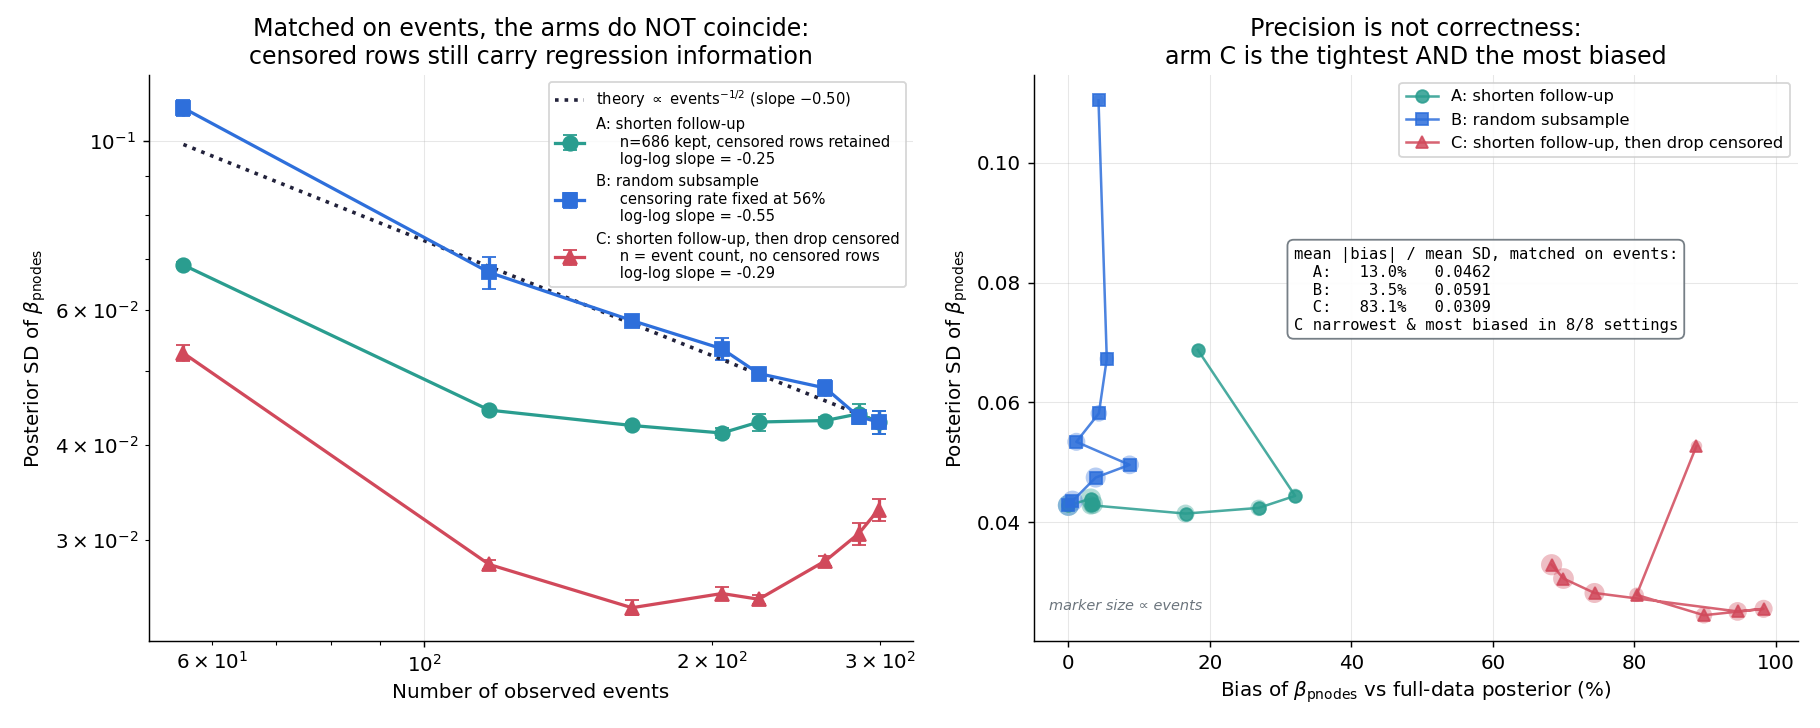

In [10]:
display(Image(os.path.join(FIG, '07_information_cost.png')))

### 機制:三臂丟掉的東西不一樣

- **B 臂**貼合理論 $\propto \text{events}^{-1/2}$(斜率約 $-0.55$):整個人被拿掉,
  設計矩陣的變異度跟著縮小,精度按教科書的速率退化。
- **A 臂**幾乎持平(斜率約 $-0.25$):只把**結果**資訊粗化成「$T>h$」,
  686 個**特徵向量全部保留**,而迴歸係數的精度吃的正是協變量的變異度。
- **C 臂**後驗**最窄,偏差卻高達 80%**。

所以那句老智慧要講得更精確:

> **事件數主導的是基準風險與絕對時間尺度的精度;
> 迴歸係數的精度同時吃事件數與協變量變異度,而刪失觀測對後者有實質貢獻。**

臨床試驗的 event-driven 設計針對前者(固定設計下檢定治療效果的檢定力),
不能直接搬來說「刪失資料沒資訊」。

### C 臂是這個專案最值得記住的一課:精度不是正確性

C 臂只留下「在追蹤期內就發生事件」的人 —— 一個系統性偏向**短存活**的樣本。
模型看到的是一份乾淨、一致、沒有刪失的資料,於是它**很有信心**;
它只是很有信心地錯著。

把兩張圖放在一起看:

| | 第 2 張圖(偏差) | 第 7 張圖(精度) |
|---|---|---|
| 丟掉刪失 | 中位存活偏 **−56%** | 後驗 sd **最小** |

> ⚠️ **若用「後驗區間寬度」當模型品質的指標,會挑到最錯的那一個。**
> 窄的區間只代表模型對自己的假設有信心,不代表假設是對的。
> 這也是為什麼校準(A1)、樣本外驗證(本專案第 3 節)、
> 以及對照非參數基準(第 2 張圖的 Kaplan–Meier)三件事缺一不可。

這是通關標準 1 的第三個面向:第 2 張圖用**偏差**證明「刪失不是遺失資料」,
資訊實驗的 A vs B 用**精度**證明它,而 C 臂證明**這兩件事必須一起看**。

## 5. 先驗敏感度

展示結論站在什麼假設上(計劃書 §8.3)。把 $\beta$ 的先驗 sd 從 0.25 掃到 2.0
(基準 0.5,即「一個標準差的特徵變化造成 0.6~1.65 倍存活時間」)。

In [11]:
ps = RES['prior_sensitivity']
rows = [{'先驗 β sd': float(k), 'β_pnodes 後驗均值': v['pnodes_mean'],
         'β_pnodes 後驗 sd': v['pnodes_sd'], '中位存活(年)': v['median_survival']}
        for k, v in ps['runs'].items()]
display(pd.DataFrame(rows).sort_values('先驗 β sd').round(4))
print(f"相對基準(sd=0.5)的最大位移:{ps['max_rel_shift_pct']:.2f}%")
print()
print('先驗放寬 8 倍(0.25→2.0),β_pnodes 幾乎不動 → 結論由資料驅動,不是先驗。')
print('對照 B2 專案:那裡的貝氏因子只要先驗放寬 3 倍就翻盤。')
print('差別在於這裡是**參數估計**(資料充足時先驗被淹沒),')
print('B2 是**模型比較**(先驗體積直接進入邊緣似然,不會被淹沒)。')

,先驗 β sd,β_pnodes 後驗均值,β_pnodes 後驗 sd,中位存活(年)
0,0.25,-0.3235,0.0428,4.5594
1,0.50,-0.3328,0.0439,4.6197
2,1.00,-0.3333,0.0426,4.6357
3,2.00,-0.3335,0.0438,4.6430


相對基準(sd=0.5)的最大位移:2.78%

先驗放寬 8 倍(0.25→2.0),β_pnodes 幾乎不動 → 結論由資料驅動,不是先驗。
對照 B2 專案:那裡的貝氏因子只要先驗放寬 3 倍就翻盤。
差別在於這裡是**參數估計**(資料充足時先驗被淹沒),
B2 是**模型比較**(先驗體積直接進入邊緣似然,不會被淹沒)。


## 小結

- **通關標準 3 ✅**:`az.compare` 明確排序 Log-Normal > Weibull > Exponential,
  且 $p_{\mathrm{WAIC}}$ 的意義(有效參數數)已解釋並與寫出的參數數對照。
- 排序有機制解釋:Log-Normal 的風險峰值落在診斷後約 2 年,對上臨床已知的
  乳癌早期復發高峰;非參數 Nelson–Aalen 佐證。
- 誠實面:WAIC 排得很開(4.9σ),但 OOF 判別力(C-index)完全分不出來 ——
  指標必須對上你要回答的問題。
- 誠實面:Log-Normal 的族群風險峰值仍未涵蓋非參數估計的 1.4 年,
  殘餘失配要靠更靈活的基準風險才能修。
- 資訊代價實驗**否證了自己的兩個假設**:
  (1) 刪失列對迴歸係數有實質資訊,「精度只由事件數決定」是過度簡化;
  (2) 丟掉刪失反而給出**最窄**的後驗 —— 精度不是正確性,
  用區間寬度挑模型會挑到偏差 80% 的那一個。

完整限制與誠實章節見 [`../README.md`](../README.md)。